# Anomaly Detection

---

Anomaly is something that deviates from what is considered to be standard, normal, or expected. For instance, an anomaly can be an observation or data point that is significantly different from the other observations or data points in a given dataset.

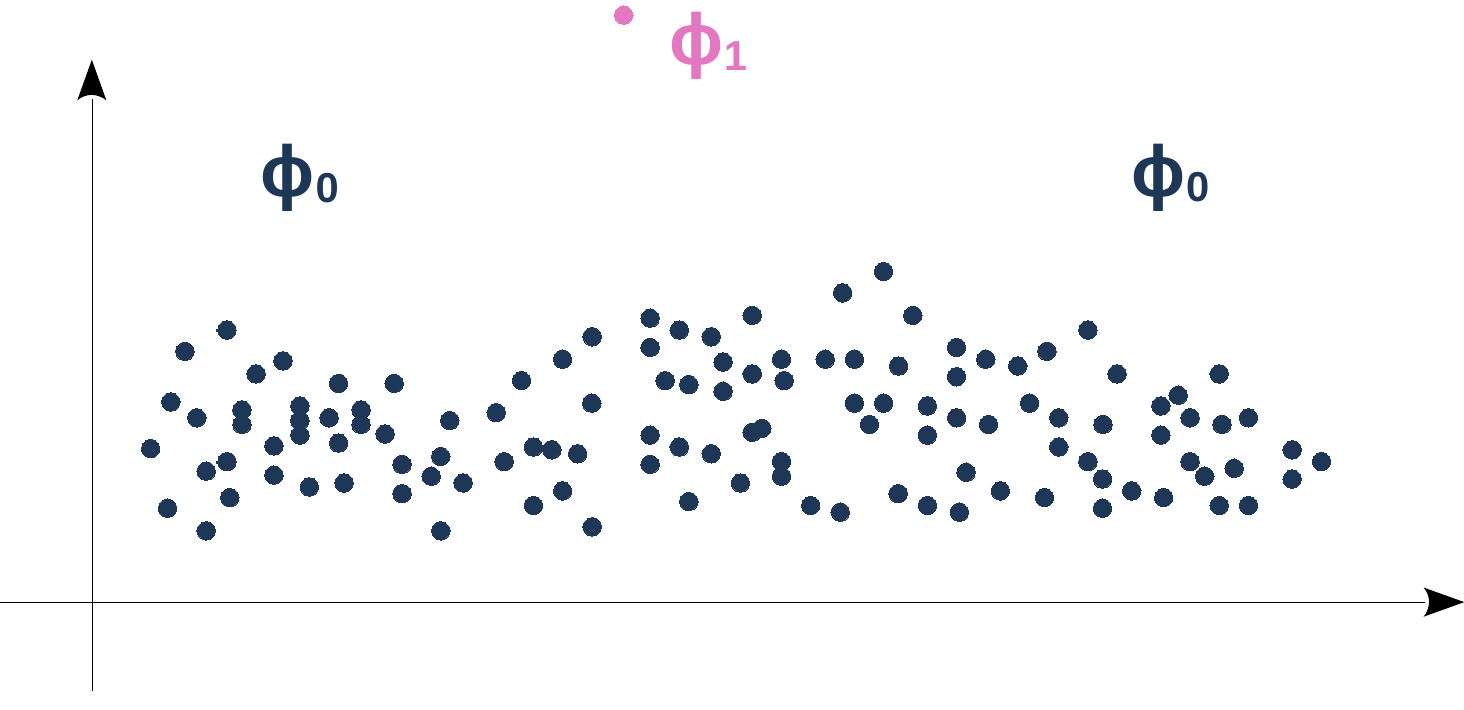

Anomaly detection is the process of identifying such anomalies or outliers in a dataset. This can involve using statistical techniques, machine learning algorithms, or other methods to identify patterns or trends that deviate significantly from the expected or normal behavior in a given system or dataset. The goal of anomaly detection is to identify and investigate these unusual patterns or data points, which may be indicative of underlying problems or issues in the system or data being analyzed.

## The anomaly detection problem

Anomalies are hard to detect for ML models since they are usually very few compared to normal data. Therefore AD datasets are imbalanced, meaning that the majority of data points belong to the "normal" class while only a small fraction of data points represent anomalies. This creates a **class imbalance problem**, where the ML model tends to be biased towards the majority class and may have difficulty detecting the minority class (anomalies). This is especially problematic since the model will overfit to the majority class and not generalizing well to the minority class.

Moreover **anomalies are unexpected** and novel types of anomalies may arise that the model has not seen before during training. This means that the ML model may not have learned to detect these new anomalies, and its performance may suffer as a result.

The following are just a few examples of the many possible applications of anomaly detection techniques. In general, any problem where detecting unusual or anomalous behavior is important can benefit from anomaly detection techniques.

* Physics: detection of particle collisions that indicate the presence of new physics beyond the Standard Model. The Large Hadron Collider (LHC) at CERN is a prime example of a particle accelerator used for this purpose. The challenge in anomaly detection in this context is to distinguish between the large number of collision events that are consistent with the Standard Model and the rare events that may indicate the presence of new physics. These anomalous events may manifest as unexpected patterns or features in the data, such as unusually high energy deposits or decay products that are inconsistent with known particles.

* Fraud Detection: Identifying fraudulent transactions or activities, such as credit card fraud, insurance fraud, or identity theft.

* Network Intrusion Detection: Detecting malicious network traffic, such as attempts to breach network security or steal sensitive data.

* Equipment Failure Prediction: Detecting potential equipment failures or malfunctions in industrial machinery, such as turbines, engines, or generators.

* Health Monitoring: Detecting abnormalities or anomalies in patient health data, such as electrocardiograms (ECGs), blood tests, or medical imaging.

* Cybersecurity: Identifying anomalous user behavior, such as unauthorized access attempts, unusual file access patterns, or abnormal data transfers.

* Predictive Maintenance: Detecting anomalous patterns in machine data, such as sensor readings or log data, to predict potential maintenance needs or equipment failures.



## A naive approch: the supervised method

Supervised machine learning models are trained on labeled data, where each data point is assigned a specific class label (e.g., "normal" or "anomaly"). These models are designed to learn the relationship between the input features and the target class labels in the training data, and then use this relationship to predict the class labels of new, unseen data.

However, supervised models can fail as anomaly detection (AD) models for several reasons:

* Supervised models require labeled data: In many real-world AD scenarios, labeled data is often not available or difficult to obtain. This can be due to the high cost or difficulty of labeling data or the fact that anomalies are rare and hard to define.

* Supervised models are biased towards the majority class: As I mentioned earlier, most datasets are imbalanced, where the majority of data points belong to the "normal" class and only a small fraction of data points represent anomalies. This creates a class imbalance problem, where supervised models tend to be biased towards the majority class and may have difficulty detecting the minority class (anomalies).

* Supervised models may not generalize well: In AD scenarios, anomalies may come in many different forms, and it can be challenging to define them precisely. Furthermore, novel types of anomalies may arise that the model has not seen before during training. This means that the supervised model may not have learned to detect these new anomalies, and its performance may suffer as a result.

## An Anomaly Detection method: The Subspace method

In the context of subspace methods, dimensionality reduction is an essential step that involves projecting high-dimensional data onto a lower-dimensional subspace. This is typically done using techniques such as principal component analysis (PCA) or singular value decomposition (SVD), which reduce the computational complexity of the AD task and help to remove noise and redundancy in the data.



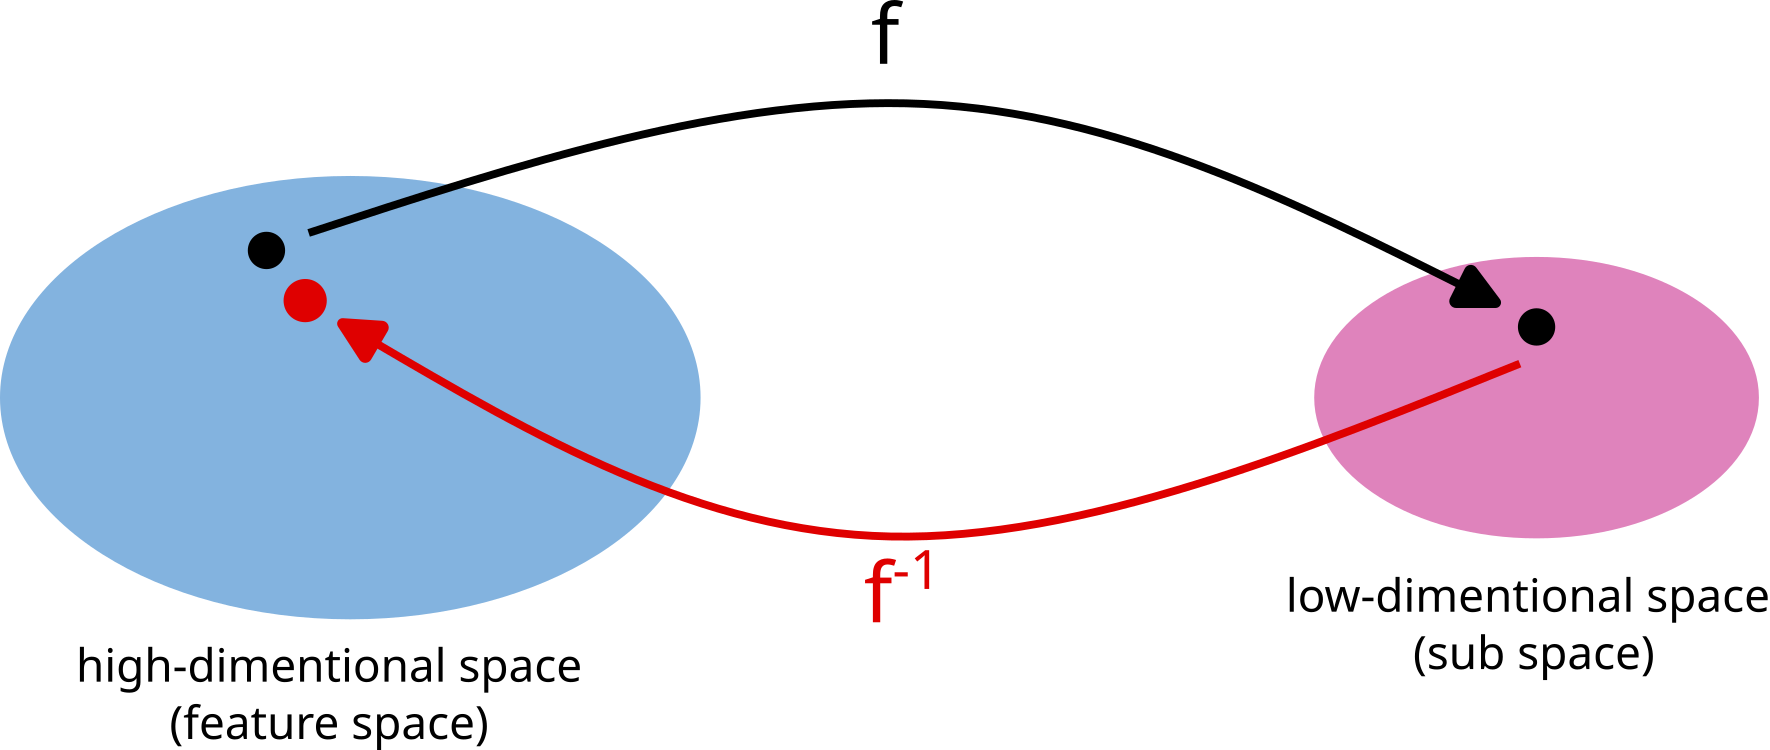

Once the subspace of normal data is estimated, anomalies are detected as data points that lie outside this subspace. This is typically done by computing the reconstruction error of each data point, which measures the distance between the original data point and its projection onto the estimated subspace. Data points with high reconstruction error are considered anomalous.

\begin{equation}
  RE({\textbf{x}_i}) = \left| (f^{-1}_\theta \circ f_\theta)(\textbf{x}_i) - \textbf{x}_i \right|^2
\end{equation}

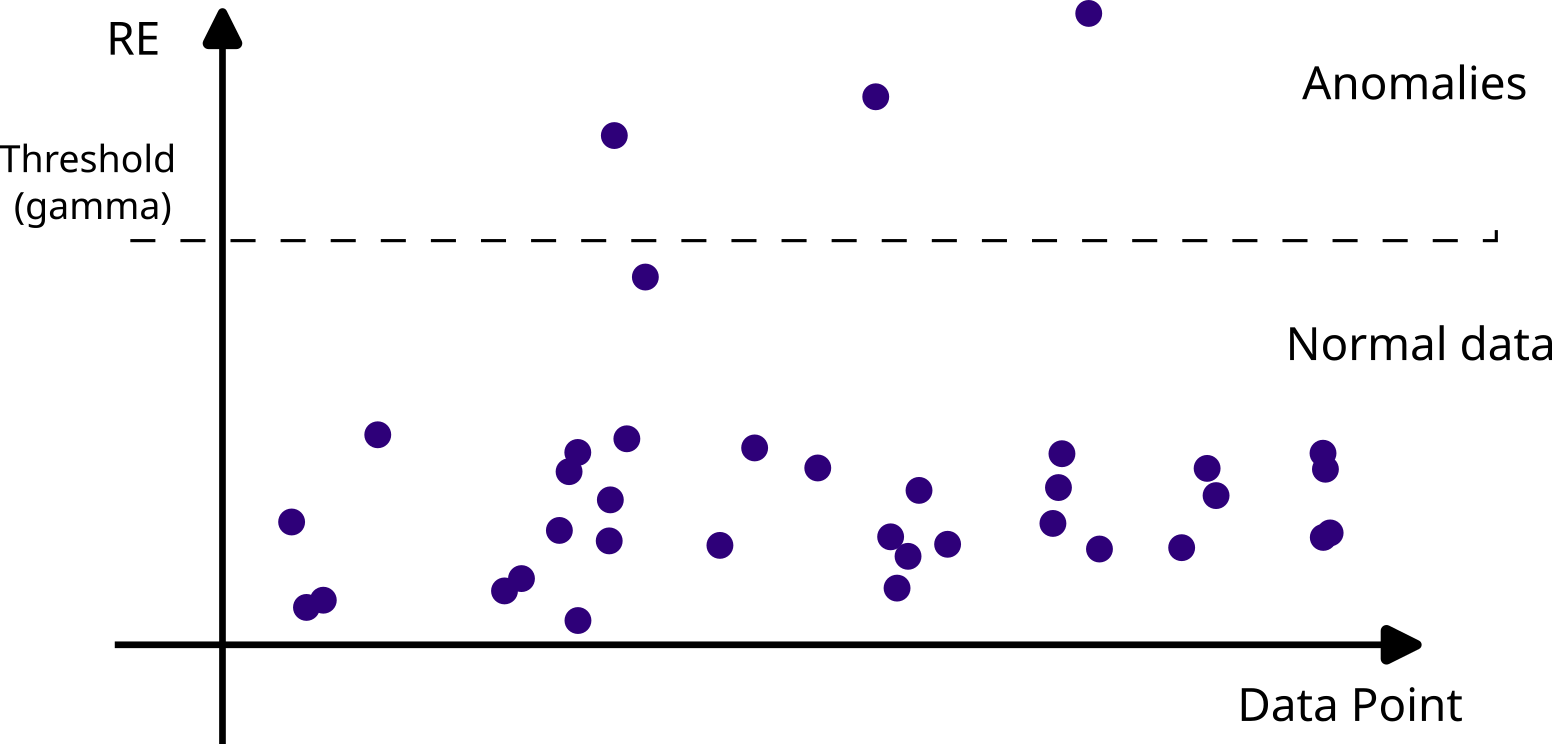

The method will detect as anomalous all those points whose RE is above a threshold (gamma). This threshold is a free parameter and its value affects the performance of the model.

The choice of the dimensionality reduction technique and the dimensionality reduction parameter can have a significant impact on the performance of the AD algorithm and should be carefully chosen based on the characteristics of the data and the specific anomaly detection task.

## Reduction methods

### Principal components analysis

PCA (Principal Component Analysis) is a commonly used technique for dimensionality reduction in machine learning and data analysis. It is a method that transforms a set of variables into a new set of variables called principal components, which are linearly uncorrelated and capture the maximum amount of variation in the original data.

The basic idea of PCA is to find a set of orthogonal axes (i.e., principal components $\vec{\alpha_i}$) that explain the maximum amount of variance in the data $\{\vec{x_i}\}_{i=1}^N$. The first principal component is the axis that captures the most variance, and each subsequent component captures the remaining variance in decreasing order.

$$ \begin{cases}
\vec{x}_1 = a_{11} \vec{\alpha}_1 +  a_{12} \vec{\alpha}_2 + ... +  a_{1n} \vec{\alpha}_n\\
...\\
\vec{x}_m = a_{m1} \vec{\alpha}_1 +  a_{m2} \vec{\alpha}_2 + ... +  a_{mn} \vec{\alpha}_m\\
\end{cases}
$$

where
$
\vec{\alpha}_i \perp \vec{\alpha}_j \,\,\,∀\,\, i \neq j
$.
For example, imagine we have a dataset with two variables: height and weight. We can plot this data as a scatterplot in a two-dimensional space, where height is on the x-axis and weight is on the y-axis. If the data points are spread out over a wide range of heights and weights, we might say that there is a lot of variance in the data.

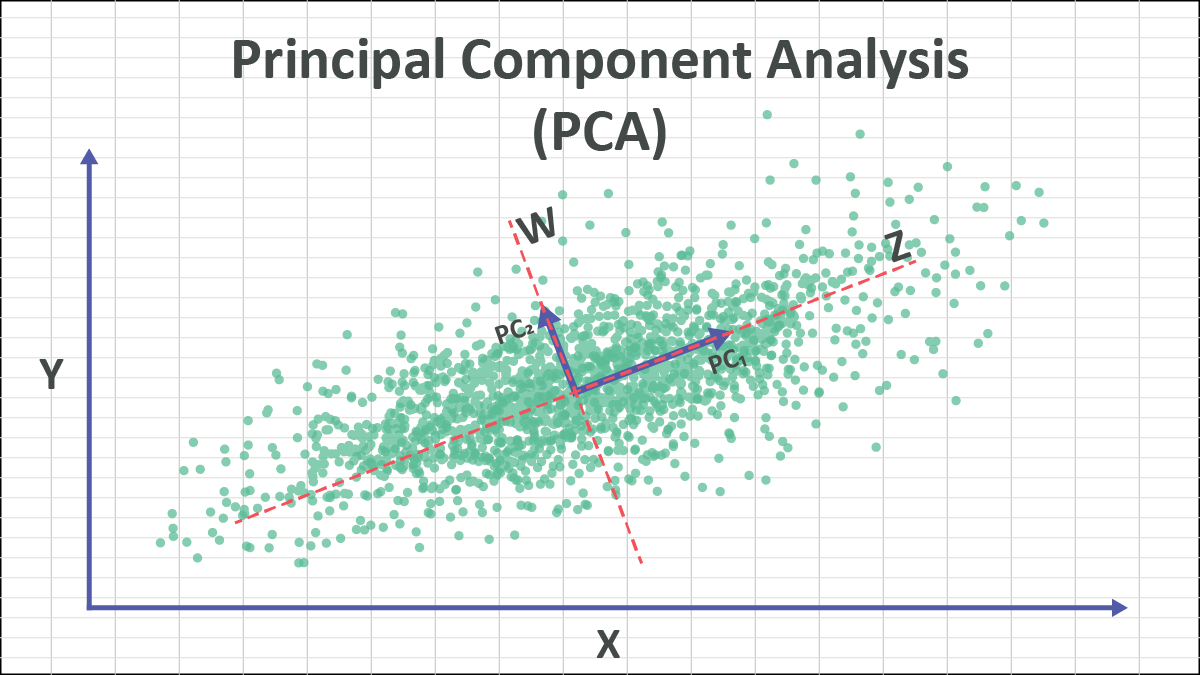

When we apply PCA to this dataset, the first principal component will represent the direction along which the data varies the most. This direction will generally not align perfectly with either the x or y axis, but will instead be some combination of the two that captures the maximum amount of variance in the data. The second principal component will then capture the remaining variance that is orthogonal (i.e., perpendicular) to the first component.

PCA works by finding the eigenvectors and eigenvalues of the covariance matrix of the data. The eigenvectors correspond to the principal components, and the eigenvalues represent the amount of variance captured by each component. The eigenvectors with the largest eigenvalues are selected as the principal components, and the data is projected onto these components.


Why variance is associated with carrying information?
- Variance is related to the question "How much something varies?"
- Information is associated to how much things are non-redundant

If data points are spreading out (high variance), it usually means there are important differences between them —> they carry information.

If data points are all close together (low variance), they are very similar, meaning there is a little amount of information (it's redundant!).

In [ ]:
from sklearn.decomposition import PCA

# Define a PCA model using 10 principal components
pca = PCA(10)

In [ ]:
# Fit the model using the data to reduce
pca.fit(training_data)

In [ ]:
# The method transform is used to apply the PCA to the data (f(x)). high-dimensionality ---> low-dimensionality
pca.transform(testing_data)

# The method transform is used to apply the inverse transofrmation to the reduced data (f^-1(x))
pca.inverse_transform(x)

## Autoencoders

Autoencoders are a type of neural network that can learn to compress and reconstruct data in an unsupervised manner. The basic idea behind an autoencoder is to train a neural network to encode an input data point into a lower-dimensional representation (known as the "code" or "latent variable"), and then decode this representation back into the original data point.

The architecture of an autoencoder typically consists of an encoder network, which takes in an input data point and outputs its corresponding code, and a decoder network, which takes in a code and outputs the corresponding reconstructed data point. The goal of training an autoencoder is to minimize the difference between the input data point and its reconstructed counterpart, using a reconstruction loss such as mean squared error.


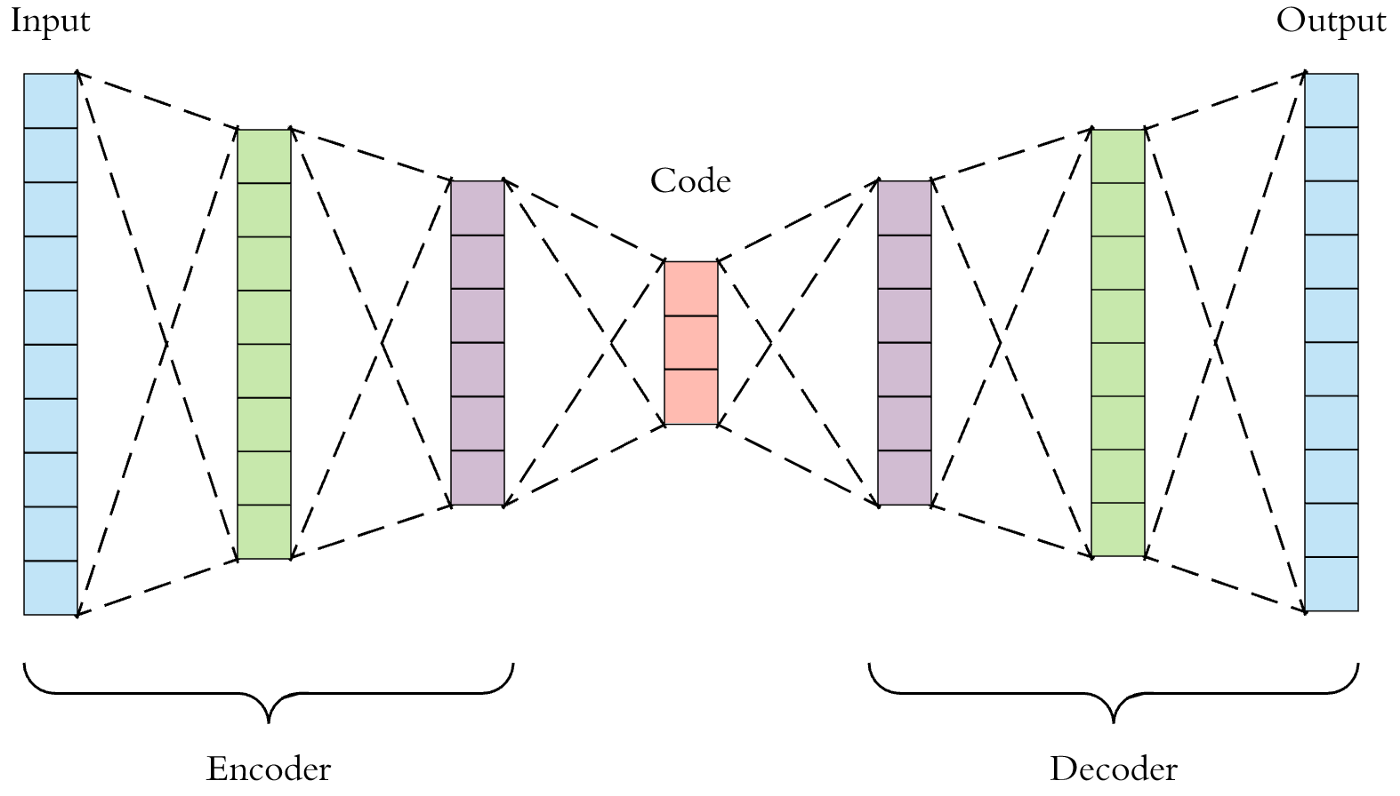

## How to measure the performance


In the context of measuring the performance of anomaly detection (AD) models, the receiver operating characteristic (ROC) curve is a commonly used tool for evaluating the trade-off between the true positive rate (TPR) and the false positive rate (FPR) of the model.

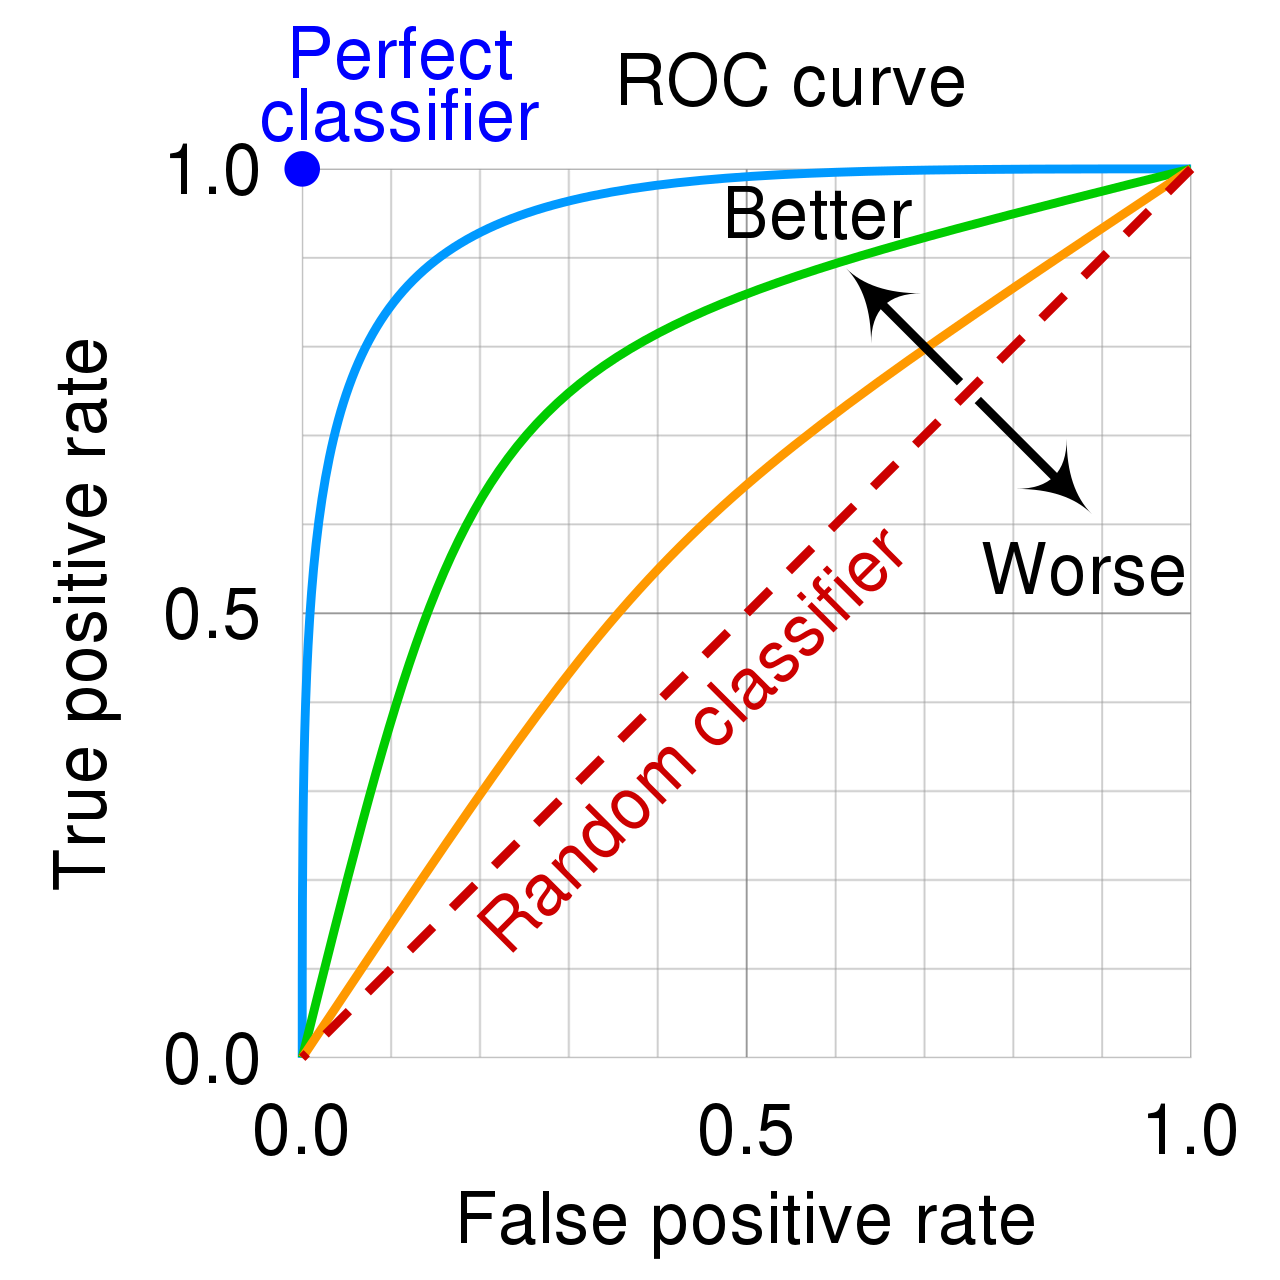

The ROC curve is a plot of the TPR on the y-axis against the FPR on the x-axis, for different thresholds of the anomaly score. The TPR is the proportion of true anomalies that are correctly identified by the model, while the FPR is the proportion of normal data points that are incorrectly identified as anomalies.

Formally, the TPR and FPR can be defined as follows:

\begin{equation}
TPR = \frac{TP}{TP + FN}
\end{equation}

\begin{equation}
FPR = \frac{FP}{FP + TN}
\end{equation}

where TP is the number of true positives (anomalies correctly identified), FN is the number of false negatives (anomalies missed by the model), FP is the number of false positives (normal data points incorrectly identified as anomalies), and TN is the number of true negatives (normal data points correctly identified).

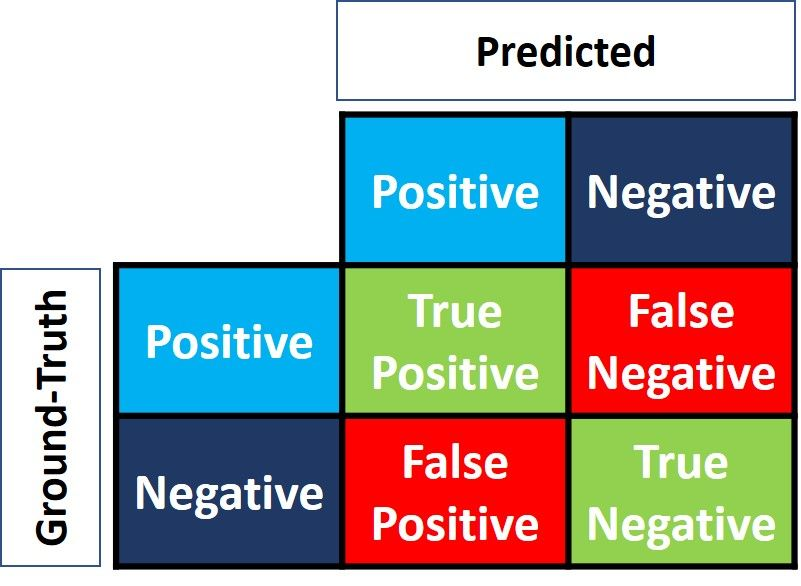



The ROC curve can be interpreted as a plot of the trade-off between sensitivity (TPR) and specificity (1-FPR) of the model, where a point on the curve corresponds to a particular threshold of the anomaly score. The area under the ROC curve (AUC-ROC) is a commonly used metric for evaluating the overall performance of the AD model, with a higher AUC-ROC indicating better performance.

## Hands-on on anomaly detection:
### 1- Detecting heart arrhythmias using PCA

**Goal:** We want to create an anomaly detection model that can detect anomalous beats in ECG signal (heart arrhythmia), using PCA

We will use a public ECG database containing 22891 beats ( 22777 normal and 114 anomalies).

**Normal Beat**
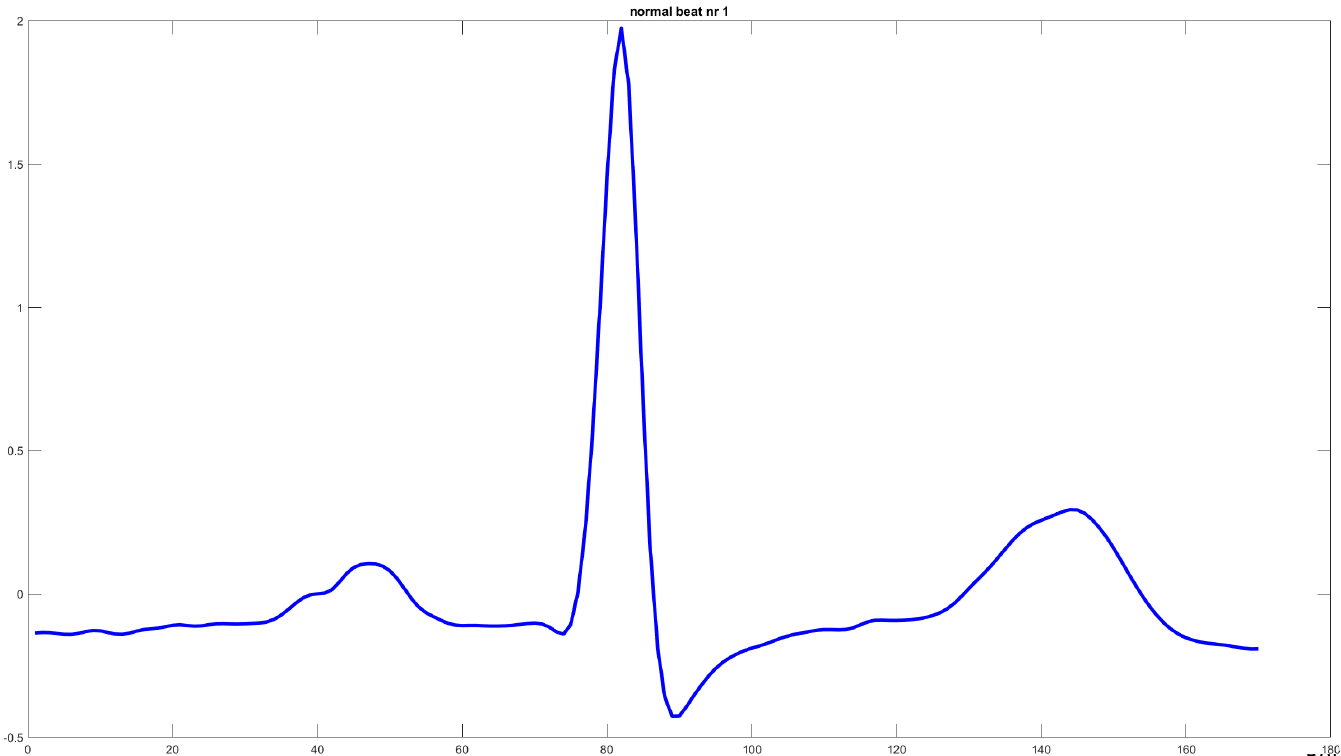

**Anomalous Beat**

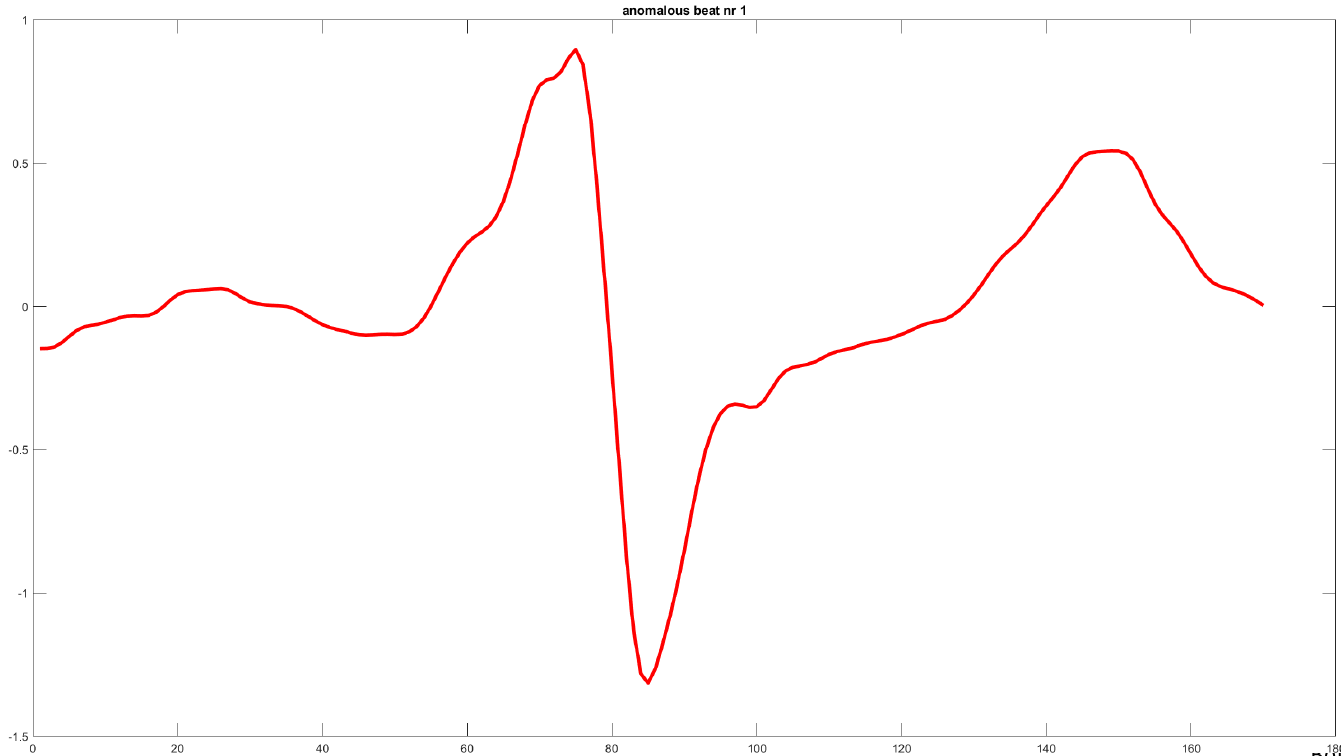

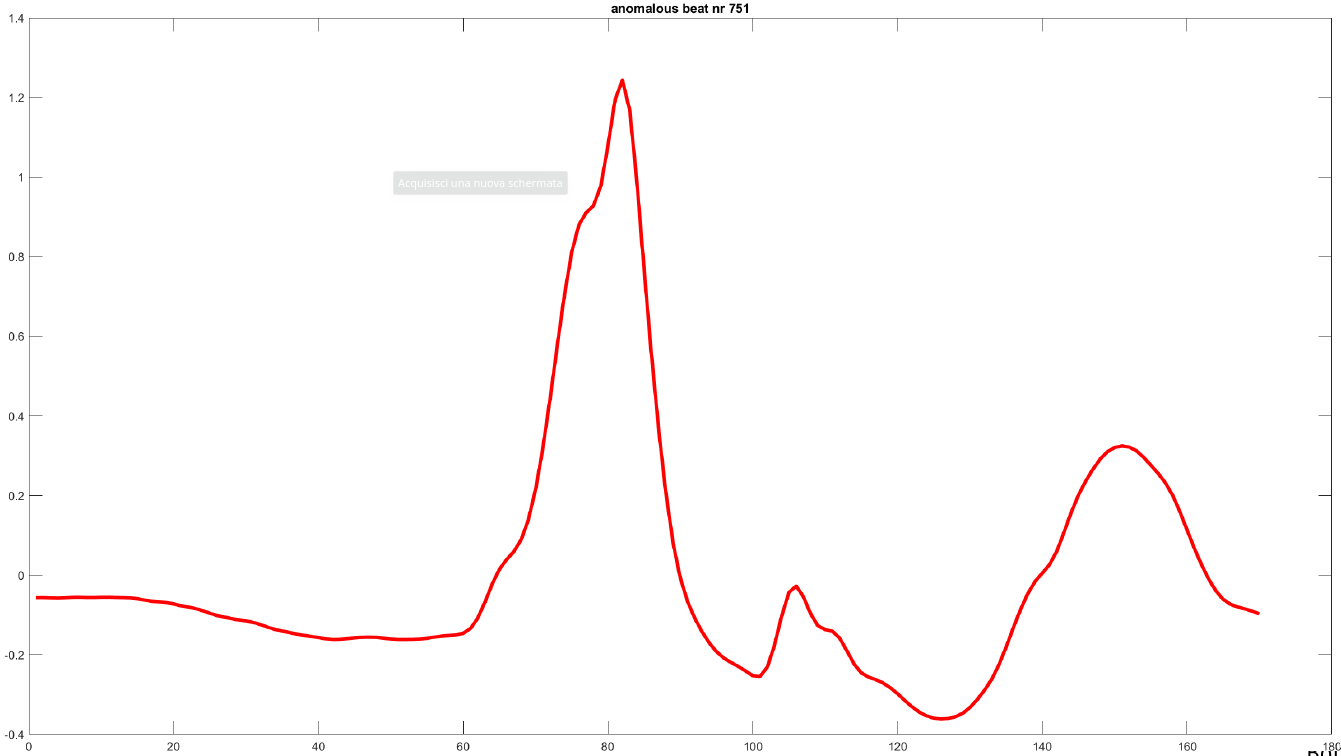

**Steps**

1.   Load the dataset. It is already divided into a training dataset and a testing dataset.
2.   Choose the number of principal components to use and train PCA on the training dataset (no labels).
3.   Calculate the reconstruction error for all testing data (Mean Absolute Error).
4.   Calculate the ROC curve and the AUC


### 2- Detecting paramagnetic anomalies in a ferromagnetic configurations dataset

Now repeat the same study using PCA on a dataset of ferromagnetic and paramagnetic spins configurations.

## Hands-on on anomaly detection: detecting heart arrhythmias using autoencoders

**Goal:** We want to create an anomaly detection model that can detect anomalous beats in ECG signal (heart arrhythmia), using an autoencoder

**Steps**

1.   Load the dataset. It is already divided into a training dataset and a testing dataset.
2.   Define a neural network autoencoder (hourglass shaped)
3.   Train the autoencoder by using normal data only.
3.   Calculate the reconstruction error for all testing data (MSE).
4.   Calculate the ROC curve and the AUC


**Hints**

Autoencoders are trained in an unsupervised manner without explicit labels. The network learns to encode the input data into a lower-dimensional representation and decode it back into the original data, with the goal of minimizing the difference between the input and reconstructed output. Therefore in the training function you should use

In [ ]:
# forward + backward + optimize
outputs = self.forward(inputs)
loss = self.criterion(inputs, outputs)
loss.backward()